In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r'C:\Users\kavitha\Downloads\creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
#Check for and handle any missing/null values.

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
#Scale the Amount column

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,scaled_amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073403


In [13]:
#Convert Time to derived feature with the formula Transaction Hour = FLOOR(Time / 3600).

df['Transaction_Hour'] = np.floor(df['Time'] / 3600)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,scaled_amount,transaction_hour,Transaction_Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244964,0,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342475,0,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.160686,0,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.140534,0,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073403,0,0.0


In [14]:
Check Class balance (count of fraud vs. non-fraud)

# Count the values in the 'Class' column
class_counts = df['Class'].value_counts()
# Display the counts
print("Class Distribution:")
print(class_counts)


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Distribution (in %):
Class
0    99.827251
1     0.172749
Name: count, dtype: float64


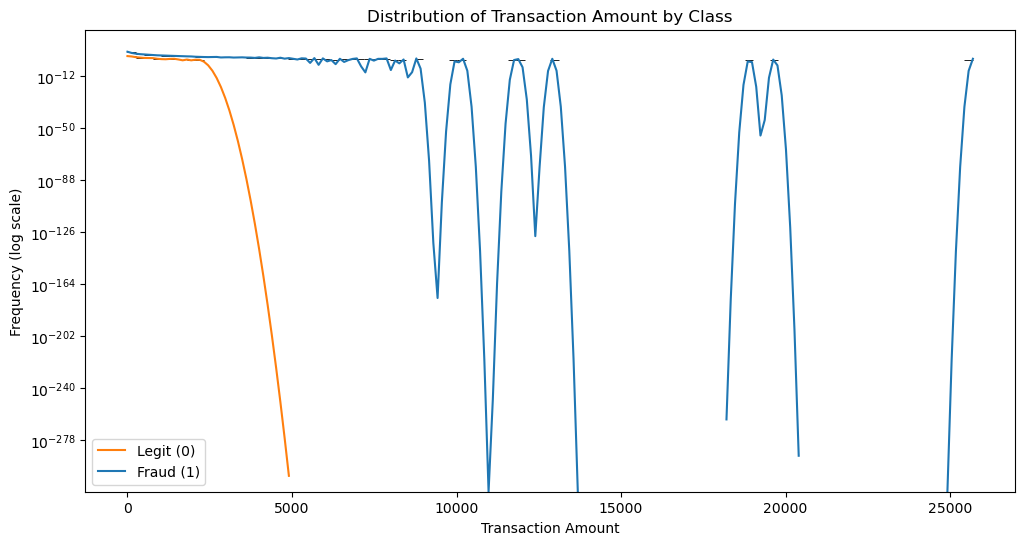

In [ ]:
#Exploratory Data Analysis (EDA)
#Distribution of Amount for fraud VS non-fraud.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Amount', hue='Class', bins=100, log_scale=(False, True), kde=True)  
plt.title('Distribution of Transaction Amount by Class')               # Kernel Density Estimate (KDE) curve on top of the histogram
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency (log scale)')
plt.legend(['Legit (0)', 'Fraud (1)'])
plt.show()


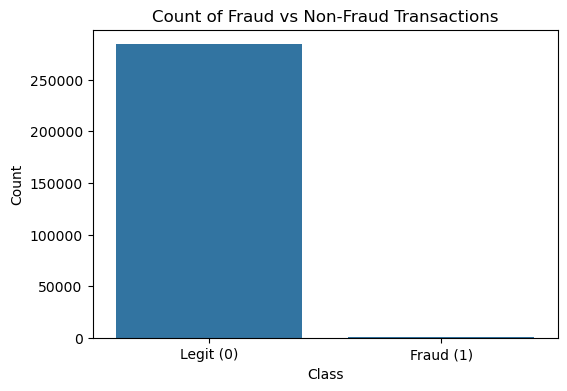

In [16]:
#Count of fraud and non-fraud transactions.

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Class')
plt.title('Count of Fraud vs Non-Fraud Transactions')
plt.xticks([0, 1], ['Legit (0)', 'Fraud (1)'])
plt.ylabel('Count')
plt.show()


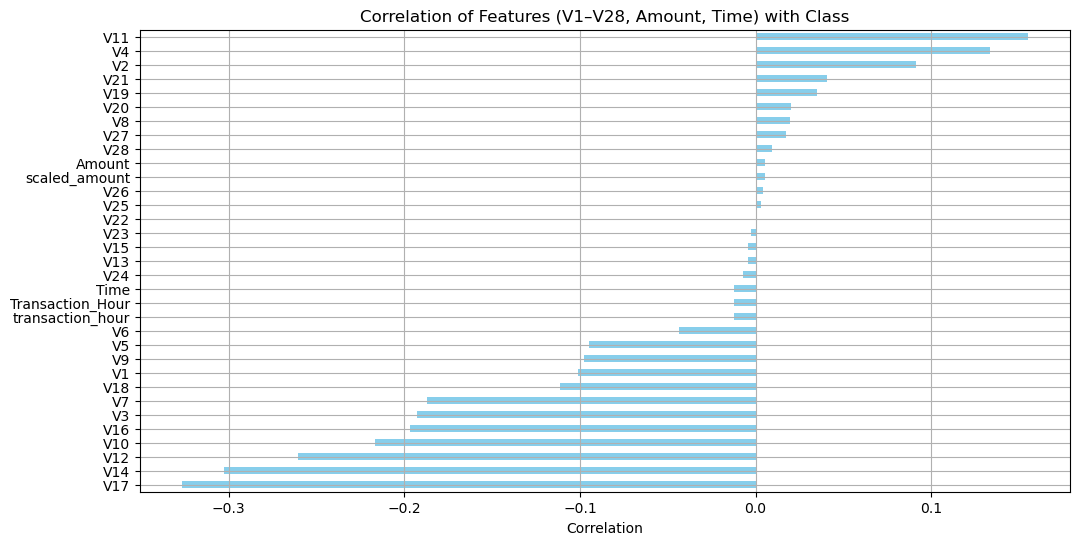

In [17]:
#Correlation heatmap of V1–V28 with Class.

corr = df.corr()['Class'].drop('Class')

plt.figure(figsize=(12, 6))
corr.sort_values().plot(kind='barh', color='skyblue')
plt.title('Correlation of Features (V1–V28, Amount, Time) with Class')
plt.xlabel('Correlation')
plt.grid(True)
plt.show()


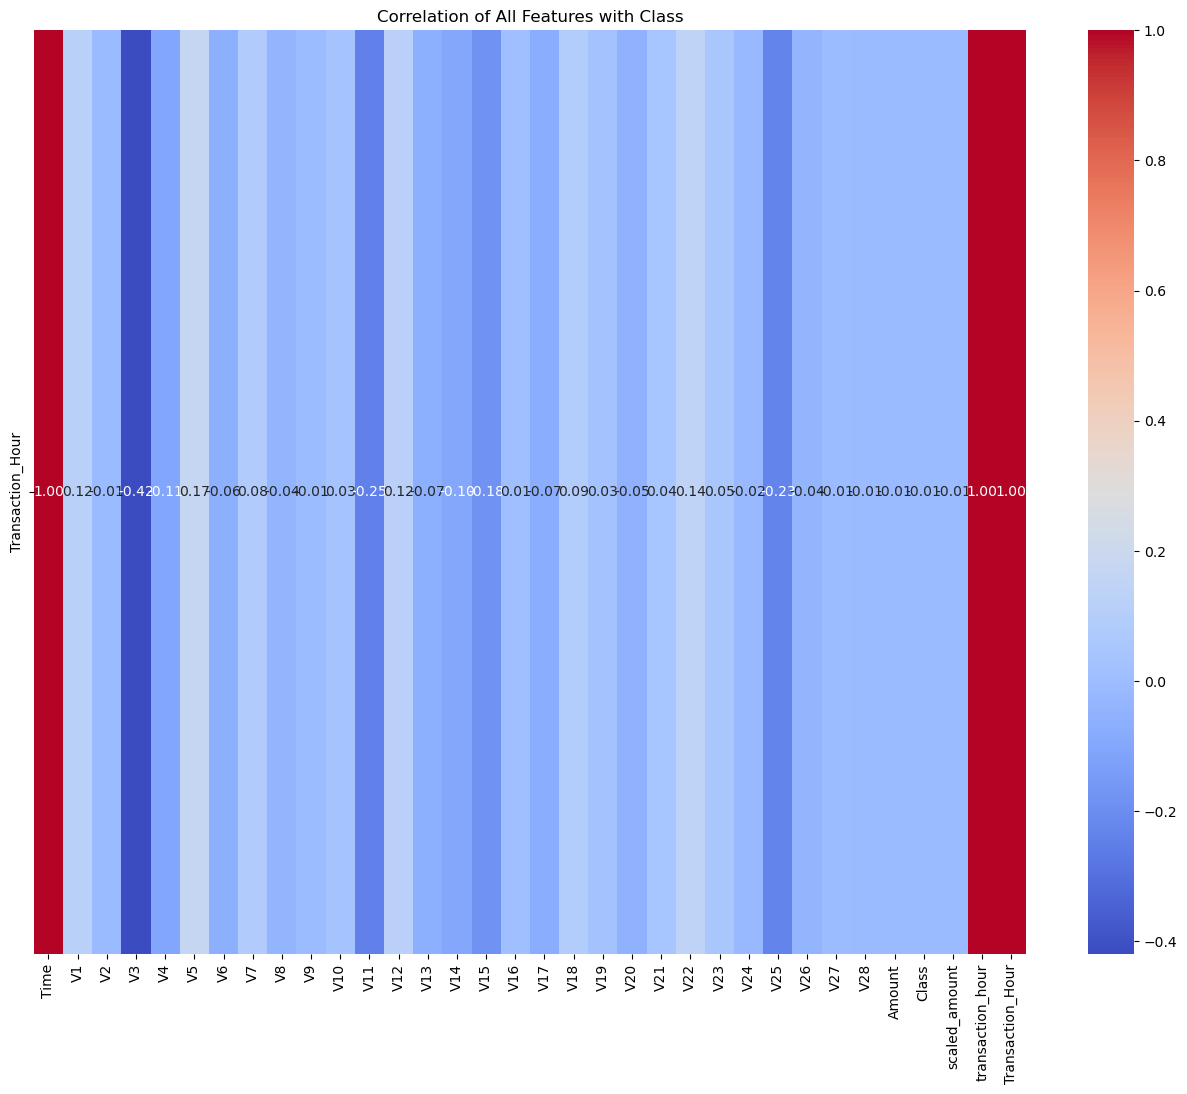

In [18]:
#For just heatmap:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr().iloc[:,-1:].T, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation of All Features with Class')
plt.show()


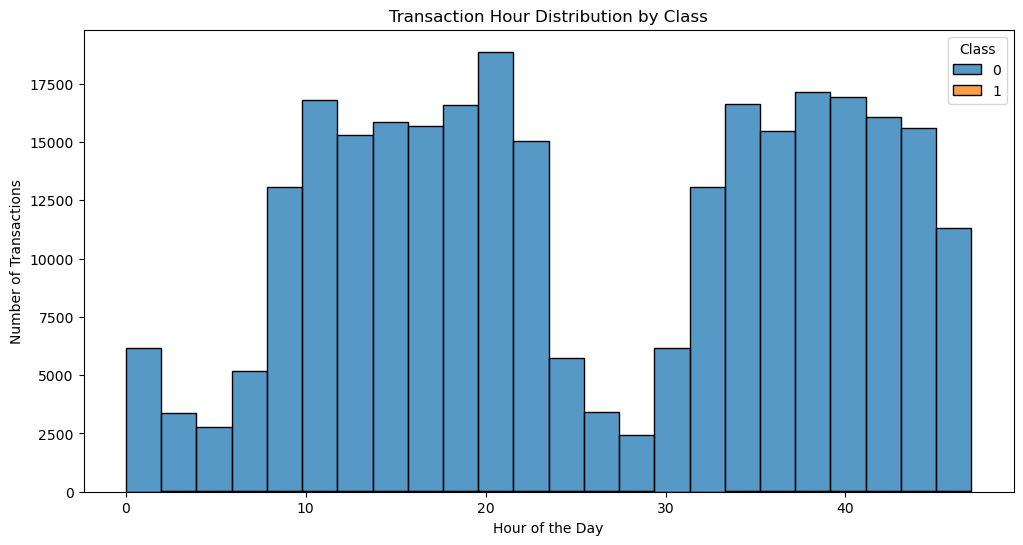

In [20]:
#Time-of-Day Patterns in Fraud (Transaction Hour)
df['Transaction_Hour'] = (df['Time'] // 3600).astype(int)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Transaction_Hour', hue='Class', multiple='stack', bins=24)
plt.title('Transaction Hour Distribution by Class')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Transactions')
plt.show()



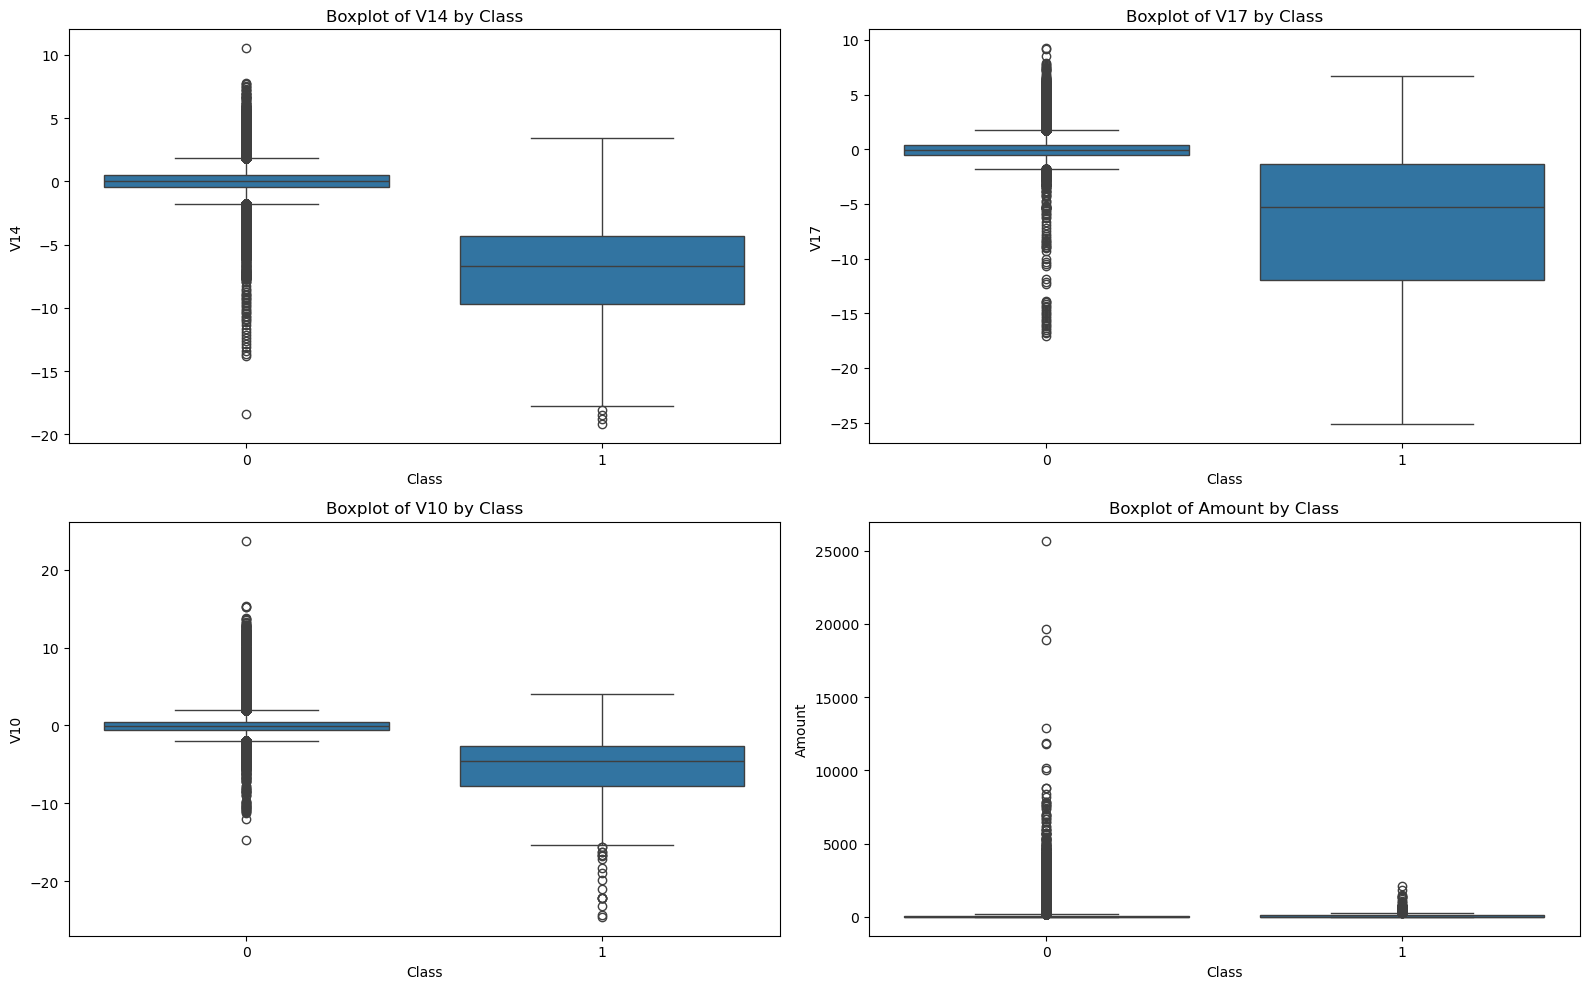

In [ ]:
#Boxplots of Selected Features by Fraud Label

features = ['V14', 'V17', 'V10', 'Amount']

plt.figure(figsize=(16, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)                    #Creates a 2x2 grid of subplots.
    sns.boxplot(data=df, x='Class', y=col)      #i + 1 ensures plots go in positions 1 to 4
    plt.title(f'Boxplot of {col} by Class')
plt.tight_layout()
plt.show()


In [22]:
#Create a Transaction Hour from Time.

df['Transaction_Hour'] = (df['Time'] // 3600).astype(int)


In [23]:
#Log-Transform Amount to Reduce Skewness

df['Log_Amount'] = np.log1p(df['Amount'])  # log1p is used to avoid log(0)

#You can check the skew before and after with:
print("Skewness before log:", df['Amount'].skew())  
print("Skewness after log:", df['Log_Amount'].skew())


Skewness before log: 16.977724453761024
Skewness after log: 0.1627029277416401


In [25]:
#Create a Binary Flag for High-Amount Transactions

high_amount_threshold = df['Amount'].quantile(0.75)

df['High_Amount_Flag'] = (df['Amount'] > high_amount_threshold).astype(int)
print(f"High amount threshold: {high_amount_threshold}")



High amount threshold: 77.16499999999999


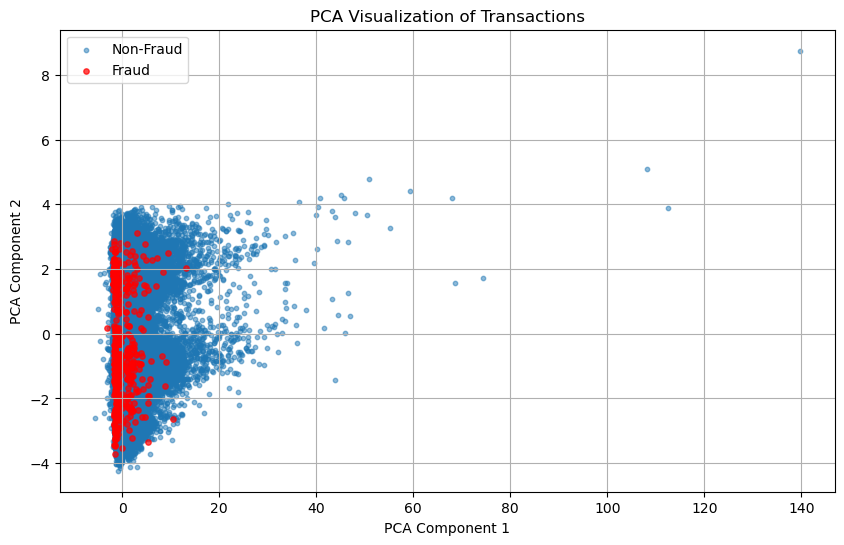

In [ ]:
#PCA / Dimensionality Reduction: Visualize Separability of Classes

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select features (excluding target and non-scalable ones)
features = df.drop(['Class', 'Time'], axis=1)

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)           #StandardScaler makes each feature have:Mean = 0,Standard deviation = 1

# Apply PCA to reduce to 2 components                      #n_components=2 means you’re reducing all features into just 2 new features (principal components)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(pca_components[df['Class'] == 0, 0], pca_components[df['Class'] == 0, 1],
            label='Non-Fraud', alpha=0.5, s=10)
plt.scatter(pca_components[df['Class'] == 1, 0], pca_components[df['Class'] == 1, 1],
            label='Fraud', alpha=0.7, s=15, color='red')
#Selects the 1st principal component (x-axis) values for all rows where the Class = 0 (i.e., non-fraud).
#pca_components is a 2D array from PCA (with shape [n_samples, 2]).
#df['Class'] == 0 filters the rows corresponding to non-fraud.


plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Visualization of Transactions')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Split the data into features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
##test_size=0.2: 20% of the data goes to testing, 80% to training.
##stratify=y: This ensures the class distribution (fraud vs. non-fraud) is the same in both train and test sets 
#very important for imbalanced datasets like fraud detection!
#(you get the same result every time you run the code).

In [34]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train the model
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluation
print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


C:\Users\kavitha\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Results:
Accuracy: 0.9706295425020189
Confusion Matrix:
 [[55199  1665]
 [    8    90]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [35]:
#Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier

# Train the model
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

# Predictions
y_pred_gb = gb.predict(X_test)

# Evaluation
print("Gradient Boosting Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Classification Report:\n", classification_report(y_test, y_pred_gb))


Gradient Boosting Results:
Accuracy: 0.9983146659176293
Confusion Matrix:
 [[56848    16]
 [   80    18]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.53      0.18      0.27        98

    accuracy                           1.00     56962
   macro avg       0.76      0.59      0.64     56962
weighted avg       1.00      1.00      1.00     56962



In [39]:
from sklearn.ensemble import RandomForestClassifier

# Train the model
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Results:
Accuracy: 0.9995084442259752
Confusion Matrix:
 [[56861     3]
 [   25    73]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)


In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]                #Predicts probabilities of the positive class (1).
                                                            #[:, 1] selects only the probability for class 1.
    print(f"\n Evaluation Metrics for {model_name}:")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))      #y_test (true labels)
    print("F1-Score :", round(f1_score(y_test, y_pred), 4))             #y_pred (labels predicted by the model)
    print("AUC-ROC  :", round(roc_auc_score(y_test, y_prob), 4))        
    print("Recall   :", round(recall_score(y_test, y_pred), 4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    return fpr, tpr, roc_auc_score(y_test, y_prob)



🔍 Evaluation Metrics for Logistic Regression:
Accuracy : 0.9706
Precision: 0.0513
Recall   : 0.9184
F1-Score : 0.0971
AUC-ROC  : 0.9741


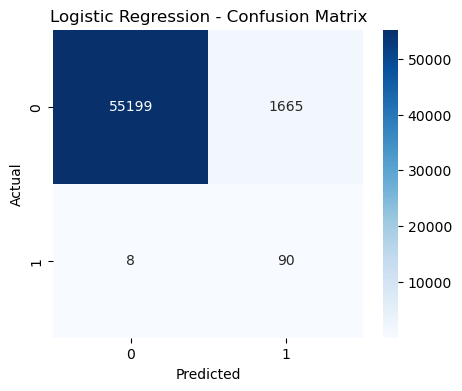


🔍 Evaluation Metrics for Random Forest:
Accuracy : 0.9995
Precision: 0.9605
Recall   : 0.7449
F1-Score : 0.8391
AUC-ROC  : 0.958


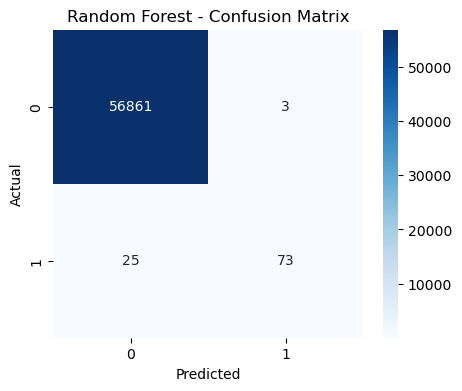

In [84]:
fpr_lr, tpr_lr, auc_lr = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")
fpr_rf, tpr_rf, auc_rf = evaluate_model(rf_model, X_test, y_test, "Random Forest")


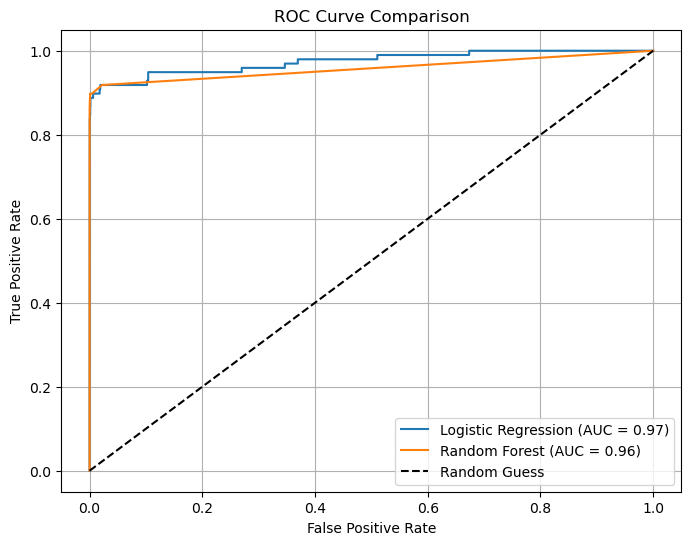

In [85]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()
